In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [3]:
from google.colab import files
uploaded = files.upload()

Saving splice[1].data to splice[1].data


In [5]:
df = pd.read_csv("splice[1].data", header=None)
df.head()

,0,1,2
0,EI,ATRINS-DONOR-521,CCAGCTGCATCACAGGAGGCCAGCGAGCAGG...
1,EI,ATRINS-DONOR-905,AGACCCGCCGGGAGGCGGAGGACCTGCAGGG...
2,EI,BABAPOE-DONOR-30,GAGGTGAAGGACGTCCTTCCCCAGGAGCCGG...
3,EI,BABAPOE-DONOR-867,GGGCTGCGTTGCTGGTCACATTCCTGGCAGGT...
4,EI,BABAPOE-DONOR-2817,GCTCAGCCCCCAGGTCACCCAGGAACTGACGTG...


In [6]:
df = df[[0,2]]
df.columns = ["label", "sequence"]

df.head()

,label,sequence
0,EI,CCAGCTGCATCACAGGAGGCCAGCGAGCAGG...
1,EI,AGACCCGCCGGGAGGCGGAGGACCTGCAGGG...
2,EI,GAGGTGAAGGACGTCCTTCCCCAGGAGCCGG...
3,EI,GGGCTGCGTTGCTGGTCACATTCCTGGCAGGT...
4,EI,GCTCAGCCCCCAGGTCACCCAGGAACTGACGTG...


In [7]:
allowed = set("ACGT")

df["sequence"] = df["sequence"].apply(
    lambda s: ''.join(c if c in allowed else 'N' for c in s)
)

In [8]:
X = df["sequence"].apply(list).apply(pd.Series)

In [9]:
X = pd.get_dummies(X)

In [10]:
y = df["label"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [13]:
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.9341692789968652
              precision    recall  f1-score   support

          EI       0.95      0.82      0.88       179
          IE       0.94      0.96      0.95       140
           N       0.92      0.99      0.95       319

    accuracy                           0.93       638
   macro avg       0.94      0.92      0.93       638
weighted avg       0.94      0.93      0.93       638



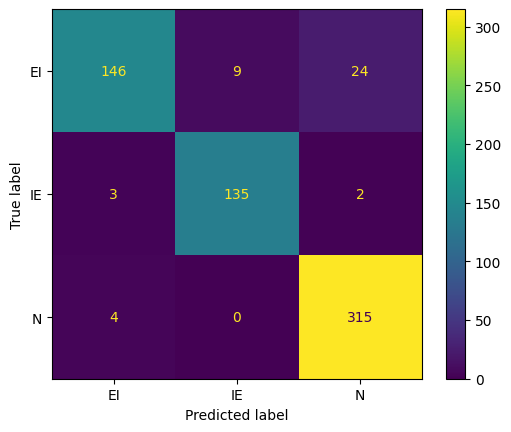

In [15]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["EI","IE","N"]
)
disp.plot()

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.9106583072100314
              precision    recall  f1-score   support

          EI       0.86      0.83      0.85       179
          IE       0.95      0.94      0.95       140
           N       0.92      0.94      0.93       319

    accuracy                           0.91       638
   macro avg       0.91      0.91      0.91       638
weighted avg       0.91      0.91      0.91       638



In [17]:
from sklearn.svm import SVC

model = SVC()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.9231974921630094
              precision    recall  f1-score   support

          EI       0.93      0.80      0.86       179
          IE       0.94      0.95      0.94       140
           N       0.91      0.98      0.95       319

    accuracy                           0.92       638
   macro avg       0.93      0.91      0.92       638
weighted avg       0.92      0.92      0.92       638



In [18]:
!pip install xgboost

In [19]:
from xgboost import XGBClassifier

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

In [23]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9655172413793104


In [24]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94       179
           1       0.96      0.97      0.97       140
           2       0.97      0.98      0.98       319

    accuracy                           0.97       638
   macro avg       0.96      0.96      0.96       638
weighted avg       0.97      0.97      0.97       638



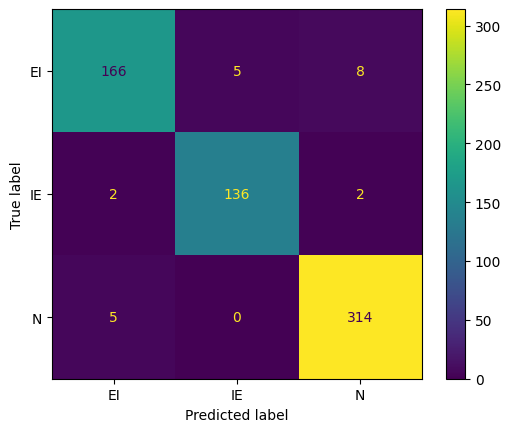

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["EI", "IE", "N"]
)

disp.plot()
plt.show()